In [13]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git
! pip install sentence-transformers

  Cloning https://github.com/openai/CLIP.git to C:\Users\marie\AppData\Local\Temp\pip-req-build-oe7tbu7d
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\marie\AppData\Local\Temp\pip-req-build-oe7tbu7d'


   ---------------------------------------- 0.0/570.8 kB ? eta -:--:--
   ---------------------------------------- 570.8/570.8 kB 3.3 MB/s  0:00:00


Importation de tous les packages nécessaires

In [14]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import numpy as np
import packaging.version
print("Torch version:", torch.__version__)
import clip
clip.available_models()
import skimage
import IPython.display
from collections import OrderedDict
from tqdm import tqdm 
import faiss
from sentence_transformers import SentenceTransformer

Torch version: 2.10.0+cpu


Test des images de la base de données Flickr8k

Fichier texte chargé !
Nombre d'images uniques : 8091 (Attendu : ~8 000)
Nombre total de descriptions : 40455 (Attendu : ~40 000)


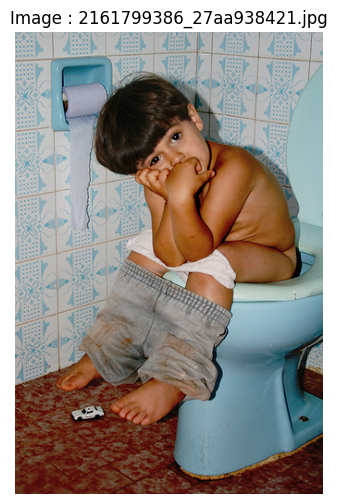

--------------------------------------------------
Descriptions associées à cette image :
--------------------------------------------------
1. A child is using the bathroom .
2. A little boy is sitting on a blue toilet with his pants pulled down .
3. A little boy sitting on a toilet with his head resting on his hands .
4. A little boy using a blue toilet .
5. A young boy sitting on a blue toilet .


In [3]:
import random

FLICKR_IMG_DIR = "../data/raw/Flickr8k_dataset/Images"
FLICKR_TEXT_FILE = "../data/raw/Flickr8k_dataset/captions.txt" 

if not os.path.exists(FLICKR_TEXT_FILE) or not os.path.exists(FLICKR_IMG_DIR):
    print("ERREUR : Les fichiers Flickr8K sont introuvables.")
    print("Assurez-vous d'avoir téléchargé le dataset depuis le repo GitHub.")
else:
    df_captions = pd.read_csv(FLICKR_TEXT_FILE, sep=',') 
    
    total_images = df_captions['image'].nunique()
    total_captions = len(df_captions)
    
    print(f"Fichier texte chargé !")
    print(f"Nombre d'images uniques : {total_images} (Attendu : ~8 000)")
    print(f"Nombre total de descriptions : {total_captions} (Attendu : ~40 000)")
if os.path.exists(FLICKR_TEXT_FILE) and os.path.exists(FLICKR_IMG_DIR):
    sample_img_name = random.choice(df_captions['image'].unique())
    
    sample_captions = df_captions[df_captions['image'] == sample_img_name]['caption'].tolist()
    img_path = os.path.join(FLICKR_IMG_DIR, sample_img_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image : {sample_img_name}", fontsize=12)
        plt.show()
        
        print("-" * 50)
        print("Descriptions associées à cette image :")
        print("-" * 50)
        for i, caption in enumerate(sample_captions, 1):
            print(f"{i}. {caption}")
    else:
        print(f"Impossible de charger l'image {sample_img_name}.")

Chargement du modèle pour les textes (multilingues afin d'avoir accès au français) et du modèle pour les images.

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Le modèle pour lire le TEXTE (multilingue)
model_texte = SentenceTransformer('clip-ViT-B-32-multilingual-v1')

# 2. Le modèle pour lire les IMAGES (standard)
model_image = SentenceTransformer('clip-ViT-B-32')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

c:\Users\marie\Documents\GitHub\Machine-and-DeepLearning-for-Multimedia-Retrieval\.venv\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\marie\.cache\huggingface\hub\models--sentence-transformers--clip-ViT-B-32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Extraction des images via le modèle

In [ ]:
images_uniques = df_captions['image'].unique()
batch_size = 32
toutes_les_features_images = []

print("Début de l'extraction des vecteurs d'images par lots...")

for i in tqdm(range(0, len(images_uniques), batch_size)):
    noms_batch = images_uniques[i : i + batch_size]
    images_ouvertes = [Image.open(os.path.join(FLICKR_IMG_DIR, nom)) for nom in noms_batch]
    features_batch = model_image.encode(
        images_ouvertes,
        batch_size=batch_size,
        show_progress_bar=False,      # a activer afin de voir la barre de progression globale 
        normalize_embeddings=True,    # Normalisation L2 pour FAISS
        convert_to_tensor=True
    )

    toutes_les_features_images.append(features_batch.cpu())
    for img in images_ouvertes:
        img.close()

embeddings_images_finaux = torch.cat(toutes_les_features_images)

print(f"\nExtraction terminée !")
print(f"Taille de la base de données d'images : {embeddings_images_finaux.shape}")

Début de l'extraction des vecteurs d'images par lots...


100%|██████████| 253/253 [06:29<00:00,  1.54s/it]


Extraction terminée !
Taille de la base de données d'images : torch.Size([8091, 512])


Extraction du texte via le modèle

In [ ]:
toutes_les_descriptions = df_captions['caption'].tolist()

print("Début de l'extraction des vecteurs de textes...")

embeddings_textes_finaux = model_texte.encode(
    toutes_les_descriptions,
    batch_size=64,
    show_progress_bar=True,       # barre de progression 
    normalize_embeddings=True,    # normalisation L2 automatiquement pour FAISS
    convert_to_tensor=True     
)

print("Extraction des textes terminée !")

Début de l'extraction des vecteurs de textes...


Batches:   0%|          | 0/633 [00:00<?, ?it/s]

Extraction des textes terminée !


In [21]:
dimension = 512 # Taille des vecteurs générés par CLIP
index_images = faiss.IndexFlatIP(dimension)

# Mise au format numpy (float32) pour FAISS
vecteurs_images_numpy = embeddings_images_finaux.numpy().astype('float32')

# Insertion de tous les vecteurs d'images dans l'index FAISS
index_images.add(vecteurs_images_numpy)
print(f"Nombre d'images dans la base FAISS : {index_images.ntotal}")

Nombre d'images dans la base FAISS : 8091


In [ ]:
# Texte de requête
texte_requete_vecteur = embeddings_textes_finaux[0].numpy().astype('float32')

# FAISS doit recevoir un tableau 2D
distances, indices = index_images.search(np.array([texte_requete_vecteur]), k=5)

print("Les indices des 5 meilleures images trouvées sont :", indices[0])
print("Leurs scores de similarité sont :", distances[0])

Les indices des 5 meilleures images trouvées sont : [2570    0 6217 7331 7292]
Leurs scores de similarité sont : [0.33282772 0.31722867 0.3149814  0.30782616 0.30673134]


Recherche en cours pour : 'Un informaticien'...


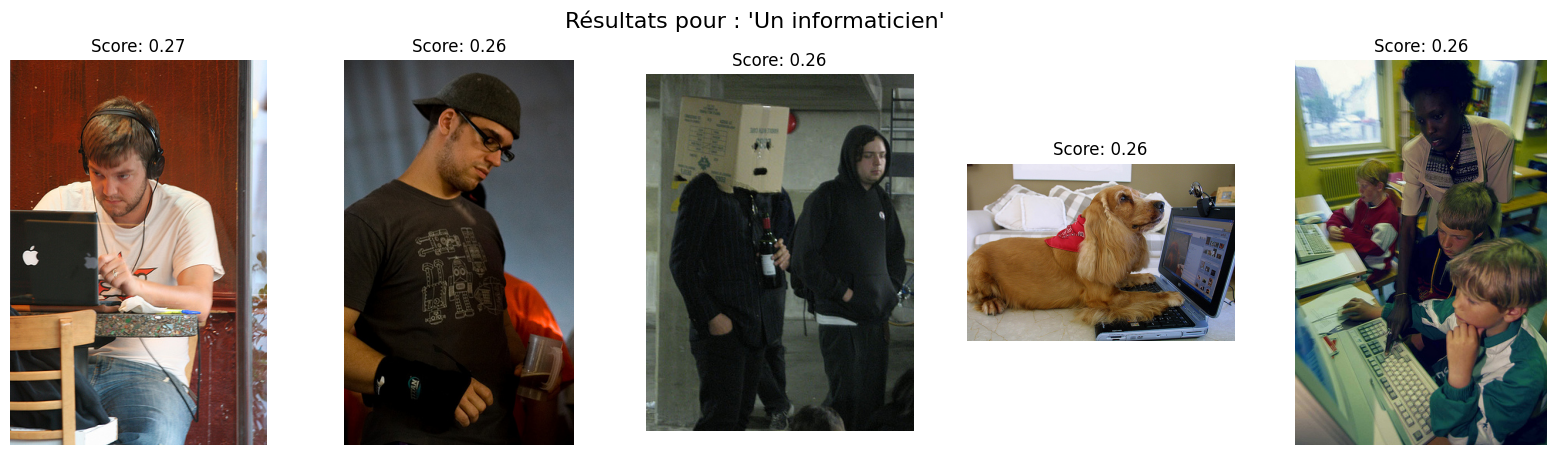

In [63]:
# On peut écrire ce que l'on veut, en français 
ma_requete = "Un informaticien"
print(f"Recherche en cours pour : '{ma_requete}'...")

# Trasnformation de la phrase en vecteur mathématique
vecteur_requete = model_texte.encode(
    [ma_requete],                
    normalize_embeddings=True     # Normalisation L2 pour FAISS
)

vecteur_faiss = np.array(vecteur_requete).astype('float32')
k = 5
distances, indices = index_images.search(vecteur_faiss, k=k) # On prend les k images kes plus proches
meilleurs_indices = indices[0]
fig, axes = plt.subplots(1, k, figsize=(20, k))
fig.suptitle(f"Résultats pour : '{ma_requete}'", fontsize=16)

for i, index_faiss in enumerate(meilleurs_indices):
    nom_image_trouvee = images_uniques[index_faiss] 
    chemin_image_trouvee = os.path.join(FLICKR_IMG_DIR, nom_image_trouvee)
    img = Image.open(chemin_image_trouvee)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Score: {distances[0][i]:.2f}")

plt.show()

Le score indiqué represente la distance mathématique entre le texte et l'image. Le but est d'avoir la plus petite distance.